In [3]:
import pandas as pd

df = pd.read_csv('/content/customer_churn.csv')

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Initial Dataset Preview

The dataset was successfully loaded into a Pandas DataFrame. The preview displays the first five customer records, including demographic details, subscribed services, billing information, and churn status.

Key observations:
- Each customer has a unique identifier.
- The dataset contains both categorical and numerical features.
- The target variable is Churn, which indicates whether a customer left the company.

## Step 2: Understanding the Dataset

In this step, we examine the dataset dimensions and column names to understand the structure of the data and identify the available features for analysis.

In [ ]:
print(df.shape)
print(df.columns)

(7043, 21)
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


## Dataset Dimensions

The dataset contains 7,043 customer records and 21 features. These features include customer demographics, subscribed services, billing information, contract details, and churn status.

## Step 3: Inspecting Data Types and Dataset Information

We review the data types of each column and check for missing values to determine whether any data cleaning is required before analysis.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Dataset Structure and Data Types

The dataset contains 7,043 records with no apparent missing values during the initial inspection. Most features are categorical, while tenure, MonthlyCharges, and SeniorCitizen are numerical variables.

An important observation is that the TotalCharges column is stored as an object data type rather than a numerical type, indicating that further preprocessing may be required.

## Step 4: Checking for Missing Values

Missing values can affect analysis and machine learning performance. We check each column to identify any null values that need to be handled.

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


## Missing Value Analysis

A missing value analysis was performed across all columns in the dataset. No null values were detected, indicating that the dataset is complete and suitable for further analysis.

## Step 5: Analyzing the Target Variable

The target variable in this project is 'Churn'. We examine its distribution to understand how many customers stayed and how many customers left the company.

In [ ]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


## Churn Distribution Analysis

The target variable 'Churn' indicates whether a customer left the company.

Analysis shows that:
- 5,174 customers remained with the company.
- 1,869 customers churned.

This represents an approximate churn rate of 26.5%, meaning that around one out of every four customers discontinued the service. Understanding the factors influencing customer churn is critical for developing effective retention strategies and improving customer satisfaction.

## Step 6: Summary Statistics

We generate descriptive statistics to understand the distribution, central tendency, and variability of numerical features in the dataset.

In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Summary Statistics

Descriptive statistics were generated for the numerical features in the dataset.

Key observations:
- Approximately 16.2% of customers are senior citizens.
- The average customer tenure is 32 months, with some customers remaining for up to 72 months.
- Average monthly charges are $64.76, ranging from $18.25 to $118.75.

These insights provide an initial understanding of customer demographics, subscription duration, and billing patterns, which may influence customer churn behavior.

In [ ]:
(df['TotalCharges'] == ' ').sum()

np.int64(11)

## Hidden Missing Values in TotalCharges

Although no null values were identified initially, further inspection revealed 11 blank entries in the TotalCharges column. These values prevent the column from being treated as a numerical variable and require preprocessing.

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df['TotalCharges'].isnull().sum()

np.int64(11)

## Converting TotalCharges to Numeric Format

The TotalCharges column was initially stored as an object data type due to the presence of blank values. The column was converted to a numeric format using pandas, and invalid entries were transformed into null values.

After conversion, 11 null values were identified, confirming the existence of hidden missing data that was not detected during the initial inspection.

In [ ]:
df = df.dropna(subset=['TotalCharges'])

print(df.shape)

(7032, 21)


## Handling Missing Values

The TotalCharges column contained 11 missing values after conversion to numeric format. Since these records represented a very small portion of the dataset, they were removed to ensure data quality and consistency.

After cleaning, the dataset contained 7,032 records and 21 features, making it suitable for further analysis and predictive modeling.

## Importing Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Churn by Contract Type

Contract type is an important factor that may influence customer retention. This analysis examines the relationship between customer contracts and churn behavior to determine whether longer-term contracts contribute to lower churn rates.

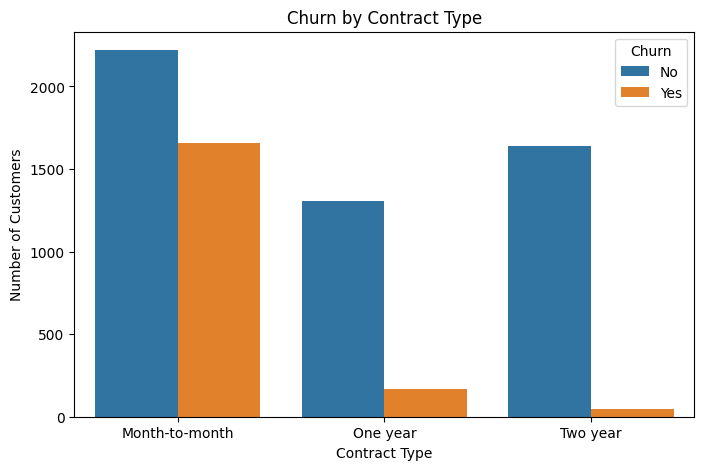

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn', data=df)

plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')

plt.show()

## Churn by Contract Type

Contract type shows a strong relationship with customer churn.

Key findings:
- Customers with month-to-month contracts exhibit the highest churn rate.
- Customers with one-year contracts show significantly lower churn.
- Customers with two-year contracts have the lowest churn rate.

This suggests that long-term contracts improve customer retention and reduce the likelihood of churn.

### Business Recommendation

The company should encourage customers to move from month-to-month contracts to long-term plans through discounts, loyalty benefits, or promotional offers. This may significantly reduce churn and improve customer retention.

## Churn by Internet Service

Internet service type may influence customer satisfaction and retention. This analysis compares churn behavior across different internet service categories.

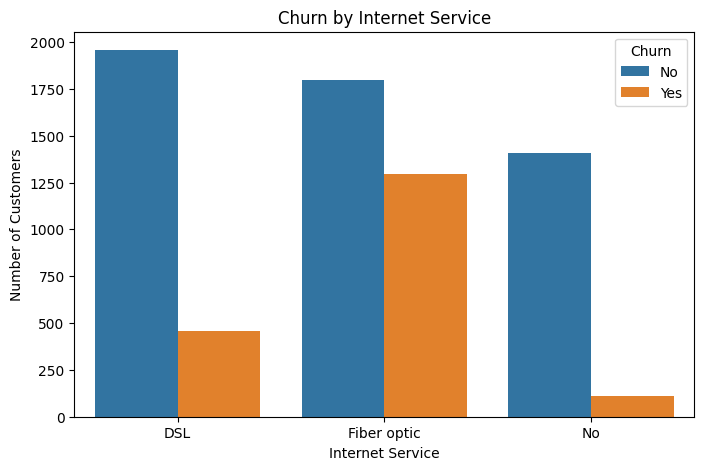

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='InternetService', hue='Churn', data=df)

plt.title('Churn by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')

plt.show()

## Churn by Internet Service

Customer churn varies considerably across internet service types.

Key findings:
- Fiber optic customers show the highest churn levels.
- DSL customers have lower churn compared to fiber optic users.
- Customers without internet service exhibit the lowest churn levels.

The results indicate that internet service quality, pricing, or customer expectations may influence churn behavior.

### Business Recommendation

The company should investigate customer satisfaction among fiber optic users. Service improvements, competitive pricing, and targeted retention campaigns may help reduce churn within this customer segment.

## Churn by Payment Method

Payment methods may influence customer retention and convenience. This analysis examines whether certain payment methods are associated with higher churn rates.

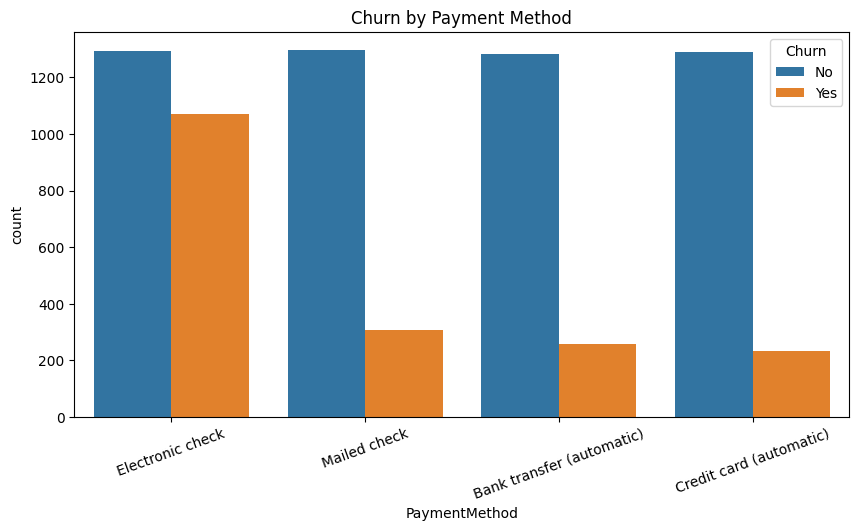

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='PaymentMethod', hue='Churn', data=df)

plt.title('Churn by Payment Method')
plt.xticks(rotation=20)
plt.show()

## Churn by Payment Method

Payment method appears to have a significant impact on customer churn behavior.

Key findings:
- Customers using Electronic Check exhibit the highest churn levels.
- Customers using Mailed Check show considerably lower churn.
- Customers using automatic payment methods such as Bank Transfer and Credit Card demonstrate the lowest churn rates.

These results suggest that customers enrolled in automatic payment systems are more likely to remain with the company.

### Business Insight

Electronic Check users are the most likely to churn. This may indicate lower customer engagement, payment inconvenience, or weaker long-term commitment compared to customers using automatic payment methods.

Customers using automatic payment options show greater retention and loyalty.

### Business Recommendation

The company should encourage customers to adopt automatic payment methods through incentives, discounts, or loyalty rewards. Increasing enrollment in automatic billing may contribute to improved customer retention and reduced churn.

## Monthly Charges vs Churn

Monthly charges may influence customer retention decisions. This analysis compares monthly billing amounts between customers who stayed and customers who churned.

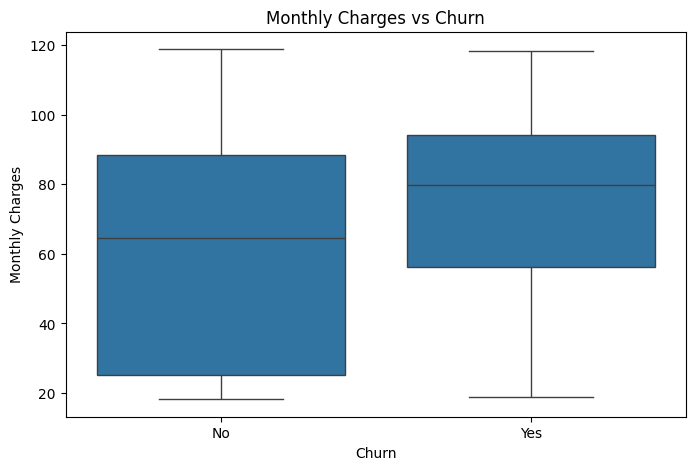

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

plt.title('Monthly Charges vs Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')

plt.show()

## Monthly Charges vs Churn

A boxplot was used to compare monthly charges between customers who remained with the company and those who churned.

Key findings:
- Customers who churned generally have higher monthly charges than customers who stayed.
- The median monthly charge is significantly higher among churned customers.
- Higher monthly costs may contribute to customer dissatisfaction and increase the likelihood of churn.

These findings suggest that pricing strategies and perceived service value may play an important role in customer retention.

### Business Insight

Customers paying higher monthly charges appear more likely to discontinue services. This indicates that pricing sensitivity may be an important driver of churn, particularly among customers receiving premium or higher-cost services.

### Business Recommendation

The company should evaluate pricing structures for higher-cost service plans and consider targeted discounts, loyalty programs, or value-added services for customers with high monthly charges. Such initiatives may improve customer satisfaction and reduce churn.

## Customer Tenure vs Churn

Customer tenure measures how long a customer has remained with the company. This analysis investigates whether customer loyalty and service duration influence churn behavior.

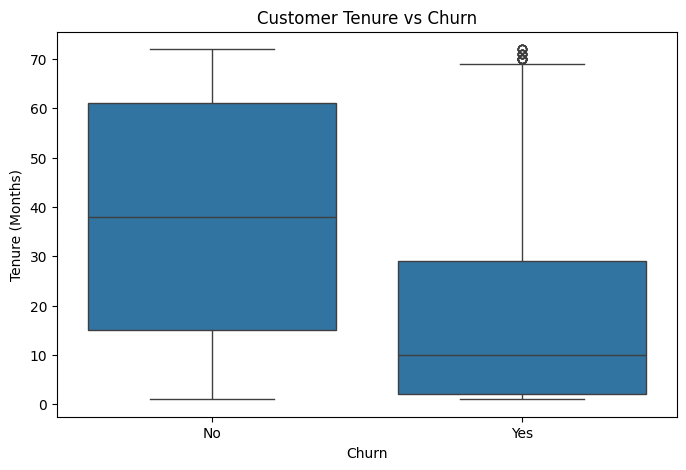

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn', y='tenure', data=df)

plt.title('Customer Tenure vs Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')

plt.show()

## Customer Tenure vs Churn

A boxplot was used to compare customer tenure between retained and churned customers.

Key findings:
- Customers who remained with the company generally have significantly longer tenure.
- Churned customers tend to leave within the early stages of their customer journey.
- The median tenure of churned customers is substantially lower than that of retained customers.

These results indicate that customer tenure is a strong predictor of churn and customer loyalty.

### Business Insight

Customers are most vulnerable to churn during the first few months after joining the company. Long-term customers demonstrate significantly higher loyalty and retention rates.

### Business Recommendation

The company should focus on improving customer onboarding and engagement during the first year of service. Personalized support, welcome offers, and early retention campaigns may help reduce churn among new customers.

# Key Findings from Exploratory Data Analysis

The exploratory data analysis identified several important factors associated with customer churn:

1. Customers with month-to-month contracts exhibit the highest churn rates.
2. Fiber optic users show significantly higher churn compared to other internet service categories.
3. Customers using electronic check payment methods are more likely to churn.
4. Higher monthly charges are associated with increased churn.
5. Customers with shorter tenure are significantly more likely to leave the company.

These findings suggest that contract type, service category, billing practices, pricing, and customer tenure play a critical role in customer retention.

# Machine Learning Model Development

The objective of this phase is to build predictive models capable of identifying customers who are likely to churn based on demographic, service, and billing characteristics.

In [4]:
# Create a copy of the cleaned dataset

ml_df = df.copy()

# Remove Customer ID because it doesn't help prediction

ml_df.drop('customerID', axis=1, inplace=True)

ml_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Encoding Categorical Variables

Machine learning algorithms require numerical input. Therefore, categorical variables were converted into numerical representations using one-hot encoding.

In [5]:
ml_df = pd.get_dummies(ml_df, drop_first=True)

ml_df.head()

,SeniorCitizen,tenure,MonthlyCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,...,TotalCharges_996.45,TotalCharges_996.85,TotalCharges_996.95,TotalCharges_997.65,TotalCharges_997.75,TotalCharges_998.1,TotalCharges_999.45,TotalCharges_999.8,TotalCharges_999.9,Churn_Yes
0,0,1,29.85,False,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0,34,56.95,True,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,0,2,53.85,True,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,0,45,42.30,True,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,0,2,70.70,False,False,False,True,False,False,True,...,False,False,False,False,False,False,False,False,False,True


## Dataset After Encoding

The dataset was transformed into a machine-learning-ready format by converting categorical features into numerical variables.

In [6]:
print(ml_df.shape)

(7043, 6560)


In [7]:
print(df['TotalCharges'].dtype)

object


In [8]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(df['TotalCharges'].dtype)

float64


In [9]:
df = df.dropna(subset=['TotalCharges'])

print(df.shape)

(7032, 21)


In [10]:
ml_df = df.copy()

ml_df.drop('customerID', axis=1, inplace=True)

ml_df = pd.get_dummies(ml_df, drop_first=True)

print(ml_df.shape)

(7032, 31)


### Note

During preprocessing, the TotalCharges column was initially treated as a categorical variable, resulting in an unusually large number of encoded features. The issue was resolved by converting TotalCharges to a numeric data type before applying one-hot encoding.

## Dataset After Encoding

Categorical variables were transformed into numerical format using one-hot encoding. After preprocessing, the dataset contained 7,032 records and 31 features, making it suitable for machine learning model development.

## Defining Features and Target Variable

The dataset was divided into independent variables (X) and the target variable (y). The target variable represents customer churn status, while all remaining features are used for prediction.

In [11]:
X = ml_df.drop('Churn_Yes', axis=1)

y = ml_df['Churn_Yes']

print(X.shape)
print(y.shape)

(7032, 30)
(7032,)


## Train-Test Split

The dataset was divided into training and testing sets. The training set is used to train the machine learning model, while the testing set is used to evaluate its performance on unseen data.

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(5625, 30)
(1407, 30)


## Logistic Regression Model

Logistic Regression was selected as the first classification algorithm to predict customer churn. It is widely used for binary classification problems and provides a strong baseline for comparison.

In [16]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

In [17]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7882018479033405


## Model Training

A Logistic Regression model was trained to predict customer churn. Logistic Regression was selected as a baseline classification algorithm due to its simplicity, interpretability, and effectiveness for binary classification problems.

## Logistic Regression Model Performance

The Logistic Regression model achieved an accuracy of 78.82% on the testing dataset.

This indicates that the model correctly classified approximately 79 out of every 100 customer records. The result demonstrates that customer demographics, service usage patterns, contract information, and billing details provide valuable information for predicting customer churn.

In [18]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[915 118]
 [180 194]]


## Confusion Matrix Analysis

The confusion matrix was used to evaluate the classification performance of the Logistic Regression model.

Results:
- 915 customers were correctly classified as retained customers.
- 194 customers were correctly classified as churned customers.
- 118 retained customers were incorrectly predicted as churned.
- 180 churned customers were incorrectly predicted as retained.

The model demonstrates good overall performance while highlighting opportunities for improvement in identifying customers at risk of churn.

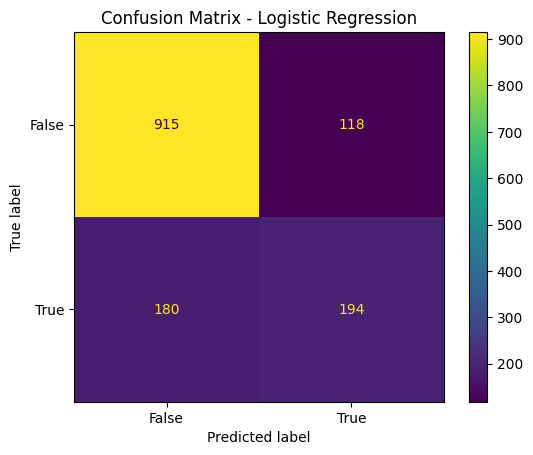

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# Project Conclusion

This project analyzed customer churn behavior using exploratory data analysis and machine learning techniques.

Key findings:
- Customers with month-to-month contracts are more likely to churn.
- Fiber optic customers exhibit higher churn rates.
- Electronic check users show increased churn behavior.
- Higher monthly charges are associated with greater churn.
- Customers with shorter tenure are significantly more likely to leave.

A Logistic Regression model was developed to predict customer churn and achieved an accuracy of 78.82%.

The results demonstrate that customer demographics, service subscriptions, billing information, and contract details can be effectively used to identify customers at risk of churn and support customer retention strategies.

## Classification Report

In addition to accuracy, a classification report was generated to evaluate precision, recall, and F1-score for both churned and retained customers.

In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.84      0.89      0.86      1033
        True       0.62      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



## Classification Report Analysis

The classification report provides a detailed evaluation of model performance using precision, recall, and F1-score.

Key findings:
- The model performs strongly when identifying retained customers, achieving an F1-score of 0.86.
- Performance for churned customers is lower, with an F1-score of 0.57.
- The overall model accuracy is 78.82%.

These results indicate that the model is effective at predicting customer retention but could be further improved in identifying customers at risk of churn.

In [21]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

feature_importance.sort_values(
    by='Coefficient',
    ascending=False
).head(10)

,Feature,Coefficient
10,InternetService_Fiber optic,1.077985
23,StreamingMovies_Yes,0.363966
21,StreamingTV_Yes,0.344132
8,MultipleLines_No phone service,0.340190
9,MultipleLines_Yes,0.282182
26,PaperlessBilling_Yes,0.277857
0,SeniorCitizen,0.260046
28,PaymentMethod_Electronic check,0.256085
5,Partner_Yes,0.052228
17,DeviceProtection_Yes,0.039277


## Feature Importance Analysis

The Logistic Regression coefficients were analyzed to identify the factors most strongly associated with customer churn.

Key findings:
- Fiber optic internet service was the strongest predictor of customer churn.
- Customers subscribed to streaming services demonstrated a higher likelihood of leaving the company.
- Electronic check payment methods were positively associated with churn.
- Senior citizens exhibited a slightly higher probability of churn compared to other customer groups.

These findings highlight customer segments that may benefit from targeted retention strategies and service improvements.

# Conclusion

This project successfully analyzed customer churn behavior using data analytics and machine learning techniques.

The dataset was cleaned, transformed, and explored to identify factors influencing customer retention. Exploratory Data Analysis revealed that contract type, internet service category, payment method, monthly charges, and customer tenure have a significant impact on churn behavior.

A Logistic Regression model was developed to predict customer churn and achieved an accuracy of 78.82%.

Key findings include:
- Month-to-month contracts are associated with higher churn rates.
- Fiber optic customers exhibit greater churn tendencies.
- Electronic check users are more likely to leave the company.
- Customers with higher monthly charges demonstrate increased churn risk.
- Customers with shorter tenure are significantly more likely to churn.

The results demonstrate how data-driven insights can help organizations identify at-risk customers and implement targeted retention strategies to improve customer loyalty and business performance.